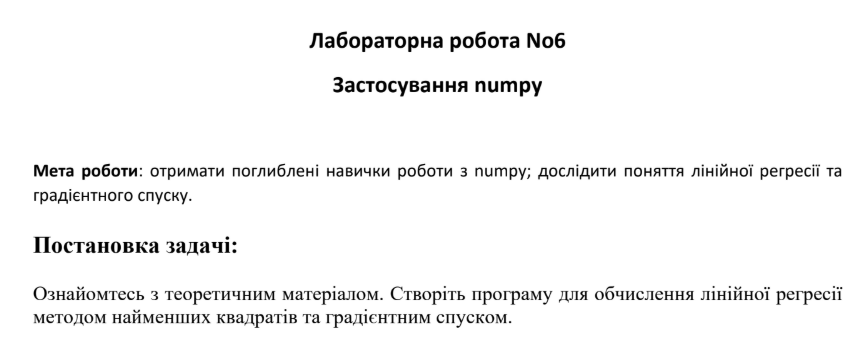

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
print("Setup Complete!")

Setup Complete!


1. Згенеруйте двовимірні дані (xx, yy) за допомогою numpy.random : бажано, щоб розподіл
точок був навколо деякої наперед заданої прямої (y = kx + b) для подальшого аналізу
результатів.

intercept: 3
slope: 8


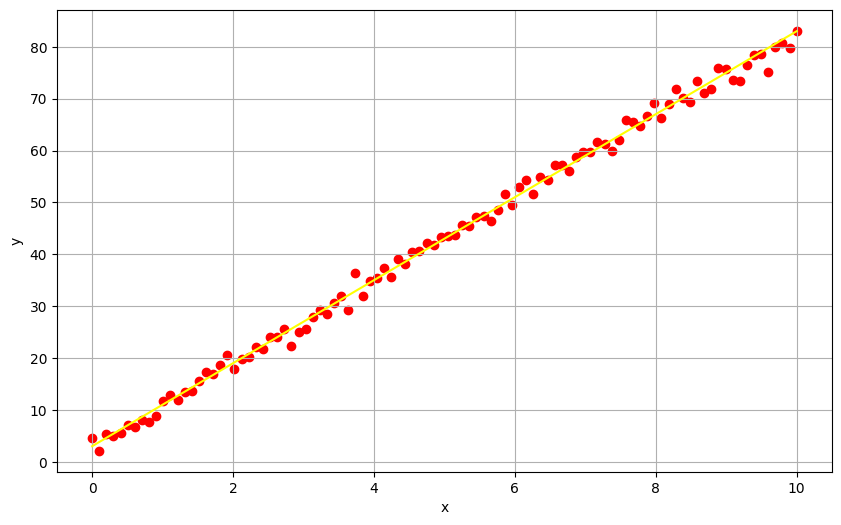

In [12]:
b_0 = np.random.randint(0, 10)  
b_1 = np.random.randint(1, 10 )  
x = np.linspace(0, 10, 100)
ε = np.random.normal(0, 1.5, 100)
y_ε = b_0 + b_1 * x + ε
y = b_1 * x + b_0
print(f"intercept: {b_0}")
print(f"slope: {b_1}")
plt.figure(figsize=(10, 6))
plt.scatter(x, y_ε, color='red', label='Дані')
plt.plot(x, b_1 * x + b_0 , color='yellow')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

2. Напишіть функцію, яка реалізує метод найменших квадратів для пошуку оптимальних
оцінок k(b_1) та b(b_0).

2. Напишіть функцію, яка реалізує метод найменших квадратів для пошуку оптимальних
оцінок k та b.

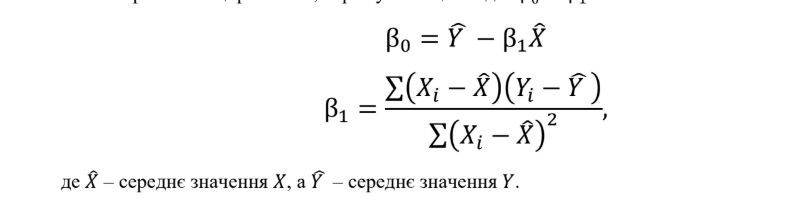

In [13]:
def least_squares_meth (x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    b_1_opt = (np.sum((x - x_mean) * (y - y_mean)))/ (np.sum((x -x_mean)**2))
    b_0_opt = y_mean - (b_1_opt * x_mean)
    return b_0_opt, b_1_opt
b_0_opt, b_1_opt = least_squares_meth(x, y_ε)
print (f"Оптимальне значення зсуву  b_0: {b_0_opt}")
print (f"Оптимальне значення коефіцієнта кута нахилу b_1: {b_1_opt}")
print(f"Коефіцієнт зсуву b_0: {b_0}") 
print(f"Кутовий коефіцієнт b_1: {b_1}")


Оптимальне значення зсуву  b_0: 3.018377207194426
Оптимальне значення коефіцієнта кута нахилу b_1: 7.980470303983249
Коефіцієнт зсуву b_0: 3
Кутовий коефіцієнт b_1: 8


3. Порівняйте знайдені параметри з оцінкою np.polyfit(x,y,1) (оцінка полінома
степеню 1 методом найменших квадратів), та з початковими параметрами прямої (якщо
такі є).

In [14]:
np_aproximation = np.polyfit(x, y_ε, 1)
b_1_np_polyfit = np_aproximation[0]
b_0_np_polyfit = np_aproximation[1] 
print(f"Коефіцієнт зсуву b_0: {b_0}") 
print(f"Кутовий коефіцієнт b_1: {b_1}")
print (f"Оптимальне значення зсуву  b_0: {b_0_opt}")
print (f"Оптимальне значення коефіцієнта кута нахилу b_1: {b_1_opt}")
print (f"Оптимальне значення зсуву polyfit b_0: {b_0_np_polyfit}")
print (f"Оптимальне значення коефіцієнта кута нахилу polyfit b_1: {b_1_np_polyfit}")

Коефіцієнт зсуву b_0: 3
Кутовий коефіцієнт b_1: 8
Оптимальне значення зсуву  b_0: 3.018377207194426
Оптимальне значення коефіцієнта кута нахилу b_1: 7.980470303983249
Оптимальне значення зсуву polyfit b_0: 3.018377207194437
Оптимальне значення коефіцієнта кута нахилу polyfit b_1: 7.98047030398325


Відобразіть на графіку знайдені оцінки лінії регресії (вашої та numpy). Якщо ви
генерували вхідні дані навколо лінії, відобразіть також її.

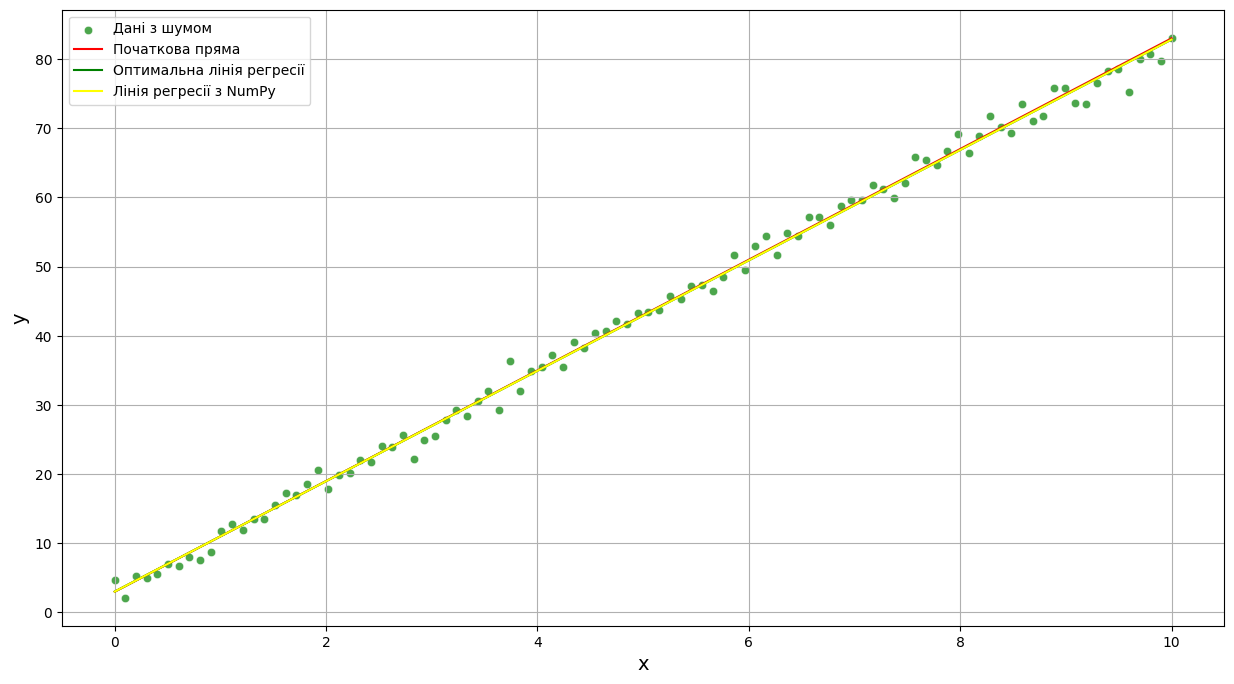

In [15]:
def plot_regression(x, ε, b_1, b_0, b_1_opt, b_0_opt, b_1_np_polyfit, b_0_np_polyfit):
    plt.figure(figsize=(15, 8))  
    sns.scatterplot(x=x, y=b_1 * x + b_0 + ε, label='Дані з шумом', color='green', alpha=0.7)  
    sns.lineplot(x=x, y=b_1 * x + b_0, color='red', label='Початкова пряма')  
    sns.lineplot(x=x, y=b_1_opt * x + b_0_opt, color='green', linestyle='solid', label='Оптимальна лінія регресії')  
    sns.lineplot(x=x, y=b_1_np_polyfit * x + b_0_np_polyfit, color='yellow', linestyle='solid', label='Лінія регресії з NumPy')  

    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)  
    plt.legend()  
    plt.grid(True)   
    plt.show()

plot_regression(x, ε, b_1, b_0, b_1_opt, b_0_opt, b_1_np_polyfit, b_0_np_polyfit)

Завдання 2:
1. Напишіть функцію, яка реалізує метод градієнтного спуску для пошуку оптимальних
оцінок k та b. Визначіть оптимальні вхідні параметри: learning_rate, n_iter

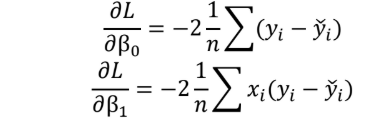

оптимальне значення b_0:2.9999999999993023 
оптимальне значення b_0:8.000000000000117 


C:\Users\User\AppData\Local\Temp\ipykernel_10248\2455100729.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


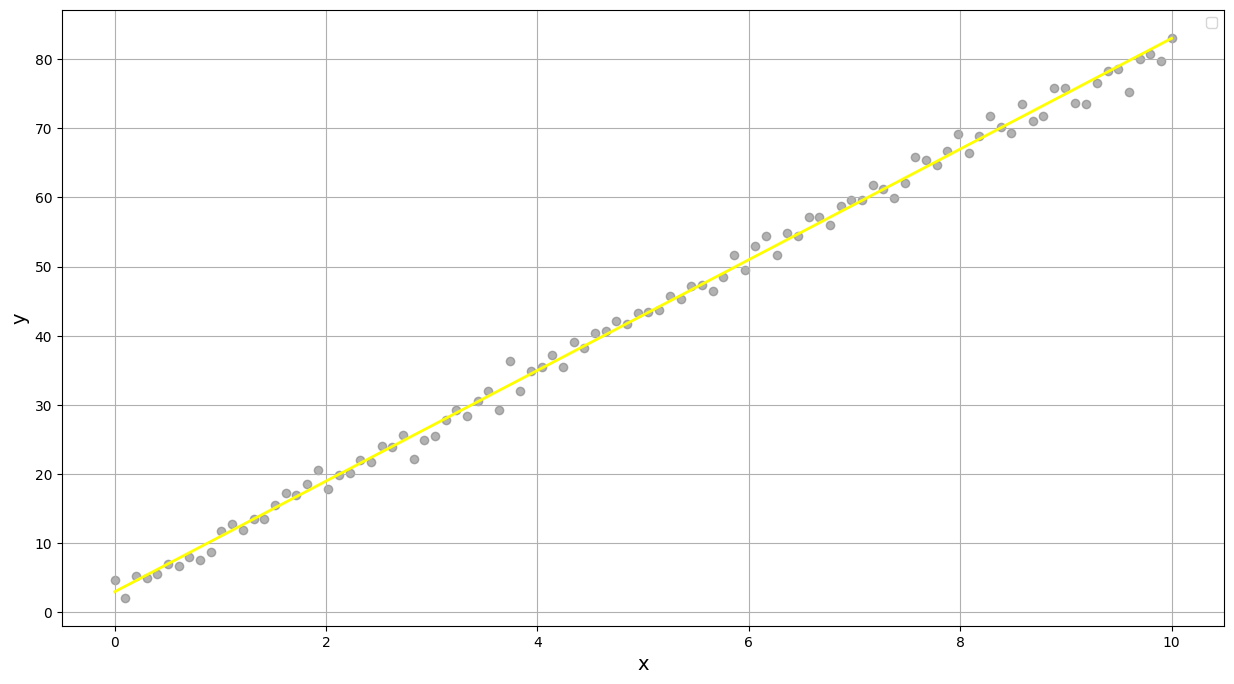

In [16]:
def gradient_descent(x, y, learning_rate=0.01, n_iter=1000):
    n = len(y)
    b_0 = 0  
    b_1 = 0  

    for _ in range(n_iter):
        y_pred = b_0 + b_1 * x

        db_0 = (-2/n) * np.sum(y - y_pred)
        db_1 = (-2/n) * np.sum(x * (y - y_pred))

        b_0 -= learning_rate * db_0
        b_1 -= learning_rate * db_1

    return b_0, b_1
learning_rate = 0.001
n_iter = 100000
b_0_gd, b_1_gd = gradient_descent(x, y, learning_rate, n_iter)
print(f"оптимальне значення b_0:{b_0_gd} ")
print(f"оптимальне значення b_0:{b_1_gd} ")

def plot_gr(x, ε, b_1_gd, b_0_gd):
    plt.figure(figsize=(15, 8))

    y_ε = b_0 + b_1 * x + ε
    plt.scatter(x, y_ε, color='gray', alpha=0.6)

    y_gd = b_1_gd * x + b_0_gd
    plt.plot(x, y_gd, color='yellow', linewidth=2)

    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()
plot_gr(x, ε, b_1_gd, b_0_gd)

2. Додайте отриману лінію регресії на загальний графік

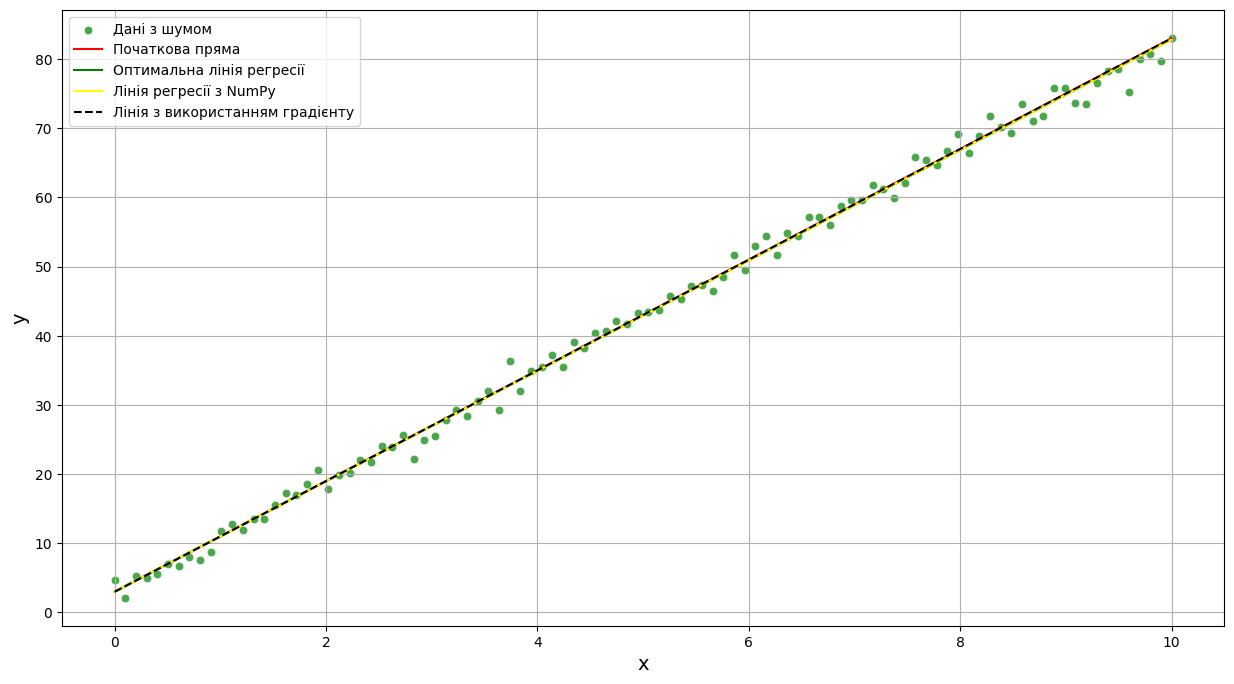

In [17]:
def plot_regression_2(x, ε, b_1, b_0, b_1_opt, b_0_opt, b_1_np_polyfit, b_0_np_polyfit, b_1_gd, b_0_gd):
    plt.figure(figsize=(15, 8))  
    sns.scatterplot(x=x, y=b_1 * x + b_0 + ε, label='Дані з шумом', color='green', alpha=0.7)  
    sns.lineplot(x=x, y=b_1 * x + b_0, color='red', label='Початкова пряма')  
    sns.lineplot(x=x, y=b_1_opt * x + b_0_opt, color='green', linestyle='solid', label='Оптимальна лінія регресії')  
    sns.lineplot(x=x, y=b_1_np_polyfit * x + b_0_np_polyfit, color='yellow', linestyle='solid', label='Лінія регресії з NumPy')
    sns.lineplot(x=x, y=b_1_gd * x + b_0_gd, color='black', linestyle = "dashed",label='Лінія з використанням градієнту')
  

    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)  
    plt.legend()  
    plt.grid(True)   
    plt.show()

plot_regression_2(x, ε, b_1, b_0, b_1_opt, b_0_opt, b_1_np_polyfit, b_0_np_polyfit, b_1_gd, b_0_gd)

3. Побудуйте графік похибки від кількості ітерацій, зробіть висновки

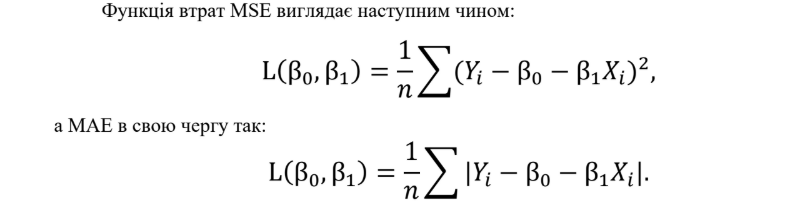

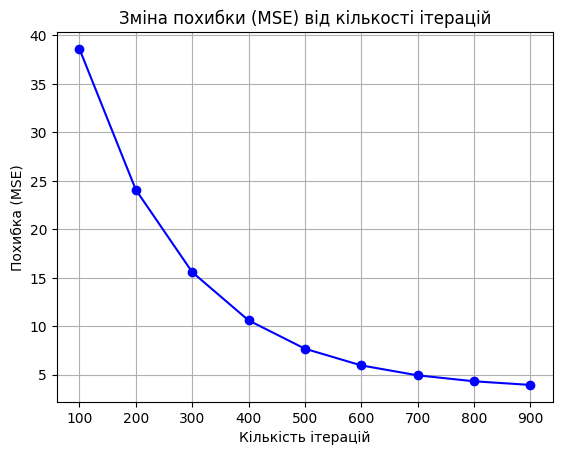

([np.float64(38.59498307882649),
  np.float64(24.065073839081364),
  np.float64(15.566920612644026),
  np.float64(10.58898665454841),
  np.float64(7.665695677578027),
  np.float64(5.941823848805935),
  np.float64(4.918308263219334),
  np.float64(4.3039178659173905),
  np.float64(3.9286985759270885)],
 [100, 200, 300, 400, 500, 600, 700, 800, 900])

In [30]:
def MSE(x, y, learning_rate=0.001, dev=0.01):
    errors = []  
    iterations = []  
    for n_iter in range(100, 1000, 100):
        b_0_grad, b_1_grad = gradient_descent(x, y, learning_rate, n_iter)  
        mse_error = np.mean((y - (b_0_grad + b_1_grad * x)) ** 2) 


        errors.append(mse_error)
        iterations.append(n_iter)

    plt.plot(iterations, errors, marker='o', color='b')
    plt.title('Зміна похибки (MSE) від кількості ітерацій')
    plt.xlabel('Кількість ітерацій')
    plt.ylabel('Похибка (MSE)')
    plt.grid(True)
    plt.show()

    return errors, iterations

x = np.random.rand(100) 
y = b_1 * x + b_0 + ε
MSE(x, y)

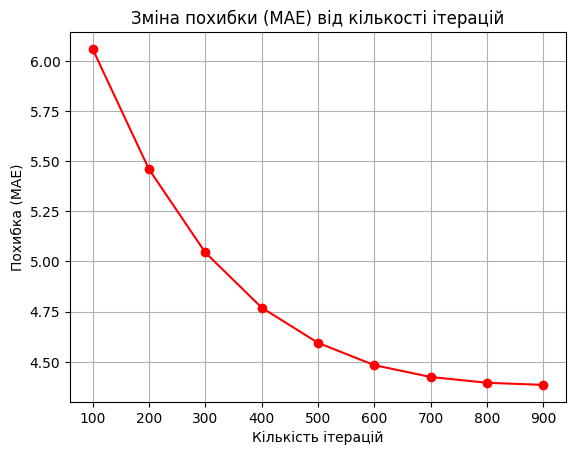

([np.float64(6.058830323659973),
  np.float64(5.459426323801222),
  np.float64(5.044274882368097),
  np.float64(4.769522328458397),
  np.float64(4.593853460791013),
  np.float64(4.482769876650851),
  np.float64(4.423827783219629),
  np.float64(4.395052884172129),
  np.float64(4.384327353707262)],
 [100, 200, 300, 400, 500, 600, 700, 800, 900])

In [29]:
def MAE(x, y, learning_rate=0.001, dev=0.01):
    errors = []  
    mae_iterations = []  
    for n_iter in range(100, 1000, 100):
        b_0_grad, b_1_grad = gradient_descent(x, y, learning_rate, n_iter)  
        mae_error = np.mean(np.abs((y - b_0_grad + b_1_grad * x)))

        errors.append(mae_error)
        mae_iterations.append(n_iter)

    plt.plot(mae_iterations, errors, marker='o', color='red')
    plt.title('Зміна похибки (MAE) від кількості ітерацій')
    plt.xlabel('Кількість ітерацій')
    plt.ylabel('Похибка (MAE)')
    plt.grid(True)
    plt.show()

    return errors, mae_iterations

x = np.random.rand(100) 
y = b_1 * x + b_0 + ε
MAE(x, y)

4. Порівняйте отримані результати з результатами попереднього завдання

In [87]:
print(f"Коефіцієнт зсуву початковий b_0: {b_0}") 
print(f"Кутовий коефіцієнт початковий b_1: {b_1}")
print(f"оптимальне значення (градієнт) b_0:{b_0_gd} ")
print(f"оптимальне значення (градієнт) b_0:{b_1_gd} ")
print (f"Оптимальне значення зсуву МНК  b_0: {b_0_opt}")
print (f"Оптимальне значення коефіцієнта кута нахилу МНК b_1: {b_1_opt}")
print (f"Оптимальне значення зсуву polyfit b_0: {b_0_np_polyfit}")
print (f"Оптимальне значення коефіцієнта кута нахилу polyfit b_1: {b_1_np_polyfit}")


Коефіцієнт зсуву початковий b_0: 4
Кутовий коефіцієнт початковий b_1: 7
оптимальне значення (градієнт) b_0:3.9999999999994356 
оптимальне значення (градієнт) b_0:7.000000000000091 
Оптимальне значення зсуву МНК  b_0: 3.9018816585344
Оптимальне значення коефіцієнта кута нахилу МНК b_1: 7.060423979381688
Оптимальне значення зсуву polyfit b_0: 3.9018816585344043
Оптимальне значення коефіцієнта кута нахилу polyfit b_1: 7.06042397938169
